In [18]:
from pyunicorn.timeseries.recurrence_plot import RecurrencePlot
from pyunicorn.timeseries.joint_recurrence_plot import JointRecurrencePlot
import recurrence as rec
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:


a, b, c = 0.2, 0.2, 5.7
k = 0.5
tau = 5.0
dt = 0.05
steps = 12000 #use 12000 to start and throw away first 2000 for transitions.

delay_steps = int(tau / dt)

# initialize arrays
xd, yd, zd = np.zeros(steps), np.zeros(steps), np.zeros(steps)
xr, yr, zr = np.zeros(steps), np.zeros(steps), np.zeros(steps)

# initial conditions
xd[0], yd[0], zd[0] = 1, 1, 1
xr[0], yr[0], zr[0] = 0, 0, 0

for i in range(steps-1):
    # drive system
    xd[i+1] = xd[i] + dt*(-yd[i] - zd[i])
    yd[i+1] = yd[i] + dt*(xd[i] + a*yd[i])
    zd[i+1] = zd[i] + dt*(b + zd[i]*(xd[i] - c))

    # delayed index
    if i > delay_steps:
        xd_tau = xd[i - delay_steps]
    else:
        xd_tau = xd[0]

    # response system
    xr[i+1] = xr[i] + dt*(-yr[i] - zr[i] + k*(xd_tau - xr[i]))
    yr[i+1] = yr[i] + dt*(xr[i] + a*yr[i])
    zr[i+1] = zr[i] + dt*(b + zr[i]*(xr[i] - c))



<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

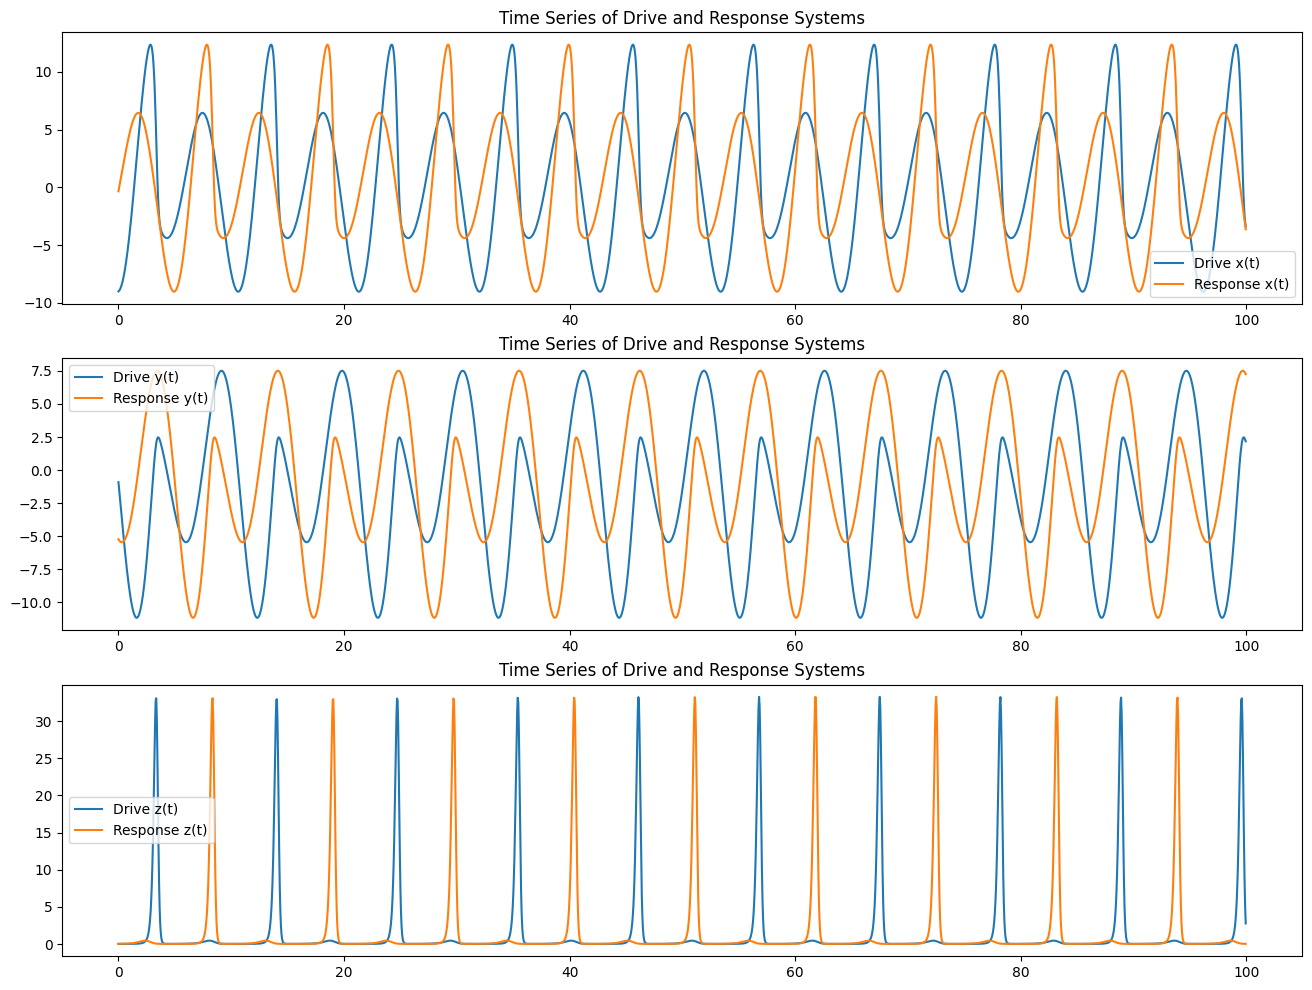

In [2]:
# plot time series
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))

steps = 2000
plt.subplot(3, 1, 1)
plt.plot(np.arange(steps)*dt, xd[2000:4000], label='Drive x(t)')
plt.plot(np.arange(steps)*dt, xr[2000:4000], label='Response x(t)')
plt.legend()
plt.title('Time Series of Drive and Response Systems')
plt.tight_layout

plt.subplot(3, 1, 2)
plt.plot(np.arange(steps)*dt, yd[2000:4000], label='Drive y(t)')
plt.plot(np.arange(steps)*dt, yr[2000:4000], label='Response y(t)')
plt.legend()
plt.title('Time Series of Drive and Response Systems')
plt.tight_layout

plt.subplot(3, 1, 3)
plt.plot(np.arange(steps)*dt, zd[2000:4000], label='Drive z(t)')
plt.plot(np.arange(steps)*dt, zr[2000:4000], label='Response z(t)')
plt.legend()
plt.title('Time Series of Drive and Response Systems')

plt.tight_layout




# plt.subplot(2, 1, 2)
# plt.plot(xd, xr, '.', alpha=0.5)
# plt.title('Phase Space: Drive vs Response')
# plt.xlabel('Drive x(t)')
# plt.ylabel('Response x(t)')
# plt.tight_layout()
# plt.show()  

In [3]:
ts3d = np.column_stack((
    xd[2000:],
    yd[2000:],
    zd[2000:]
))
print(ts3d.shape)

(10000, 3)


Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


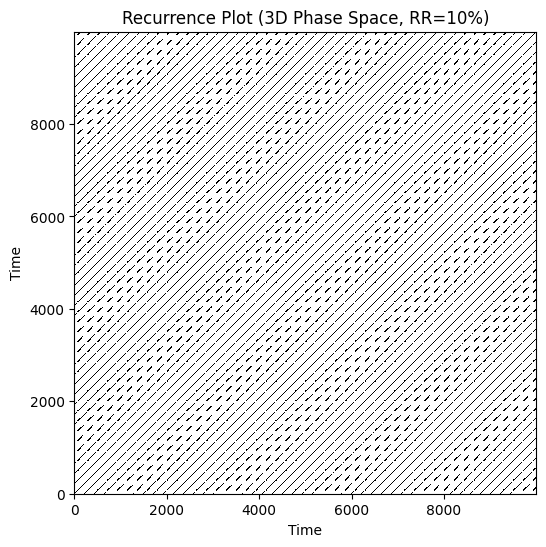

In [5]:

rp = RecurrencePlot(
    ts3d,       # 3D phase space
    recurrence_rate=0.1,  # 10% recurrence rate
    metric="euclidean"    # distance in phase space
)

R = rp.recurrence_matrix()

plt.figure(figsize=(6,6))
plt.imshow(R, origin='lower', cmap='binary', interpolation='none')
plt.title("Recurrence Plot (3D Phase Space, RR=10%)")
plt.xlabel("Time")
plt.ylabel("Time")
plt.show()

(10000, 3)
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


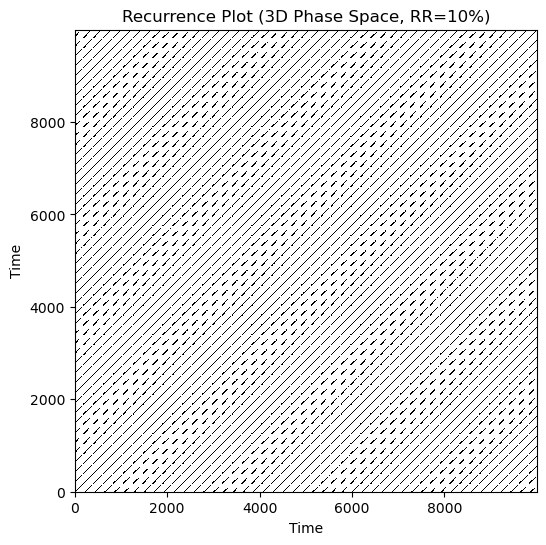

In [69]:
ts3d_r = np.column_stack((
    xr[2000:],
    yr[2000:],
    zr[2000:]
))
print(ts3d_r.shape)



rp = RecurrencePlot(
    ts3d_r,       # 3D phase space
    recurrence_rate=0.1,  # 10% recurrence rate
    metric="euclidean"    # distance in phase space
)

R = rp.recurrence_matrix()

plt.figure(figsize=(6,6))
plt.imshow(R, origin='lower', cmap='binary', interpolation='none')
plt.title("Recurrence Plot (3D Phase Space, RR=10%)")
plt.xlabel("Time")
plt.ylabel("Time")
plt.show()

Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...


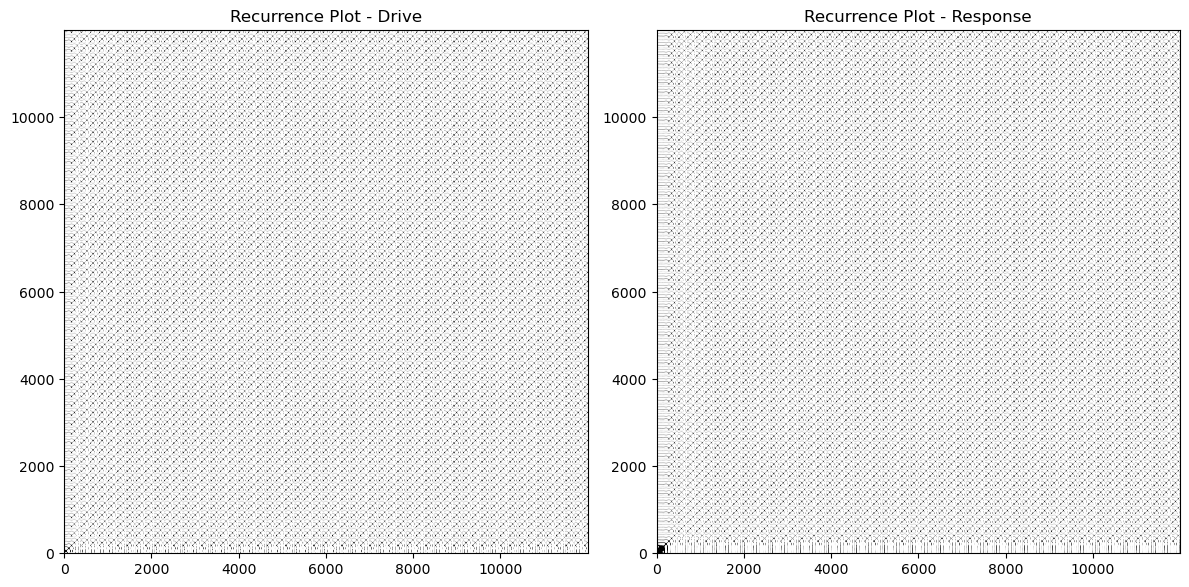

In [52]:
# plot recurrence plots
from pyunicorn.timeseries import RecurrencePlot
rp_drive = RecurrencePlot(xd, recurrence_rate=0.1)
rp_response = RecurrencePlot(xr, recurrence_rate=0.1)
RP_drive = rp_drive.recurrence_matrix()
RP_response = rp_response.recurrence_matrix()
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(RP_drive, cmap='binary', origin='lower')
ax[0].set_title('Recurrence Plot - Drive')
ax[1].imshow(RP_response, cmap='binary', origin='lower')
ax[1].set_title('Recurrence Plot - Response')
plt.tight_layout()
plt.show()

Calculating cross recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Lag from Tau Recurrence Rate: 198


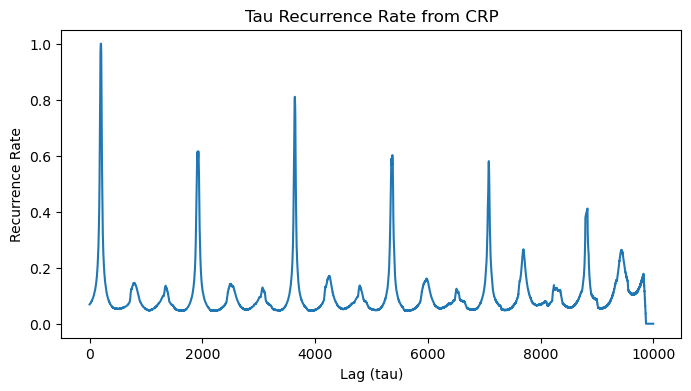

In [17]:
# Tau - Recurrence Rate

from pyunicorn.timeseries import CrossRecurrencePlot
import recurrence as rec

CRP = CrossRecurrencePlot(xd, xr, recurrence_rate=0.1).recurrence_matrix()
tau_rr = rec.tau_recurrence(CRP)

lag_tau = np.argmax(tau_rr)

print("Lag from Tau Recurrence Rate:", lag_tau)

plt.figure(figsize=(8,4))
plt.plot(tau_rr)
plt.xlabel("Lag (tau)")
plt.ylabel("Recurrence Rate")
plt.title("Tau Recurrence Rate from CRP")
plt.show()

CPR = 0.8929913173532384


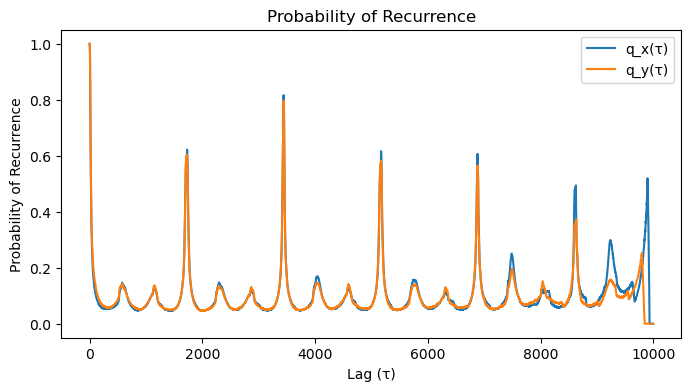

In [18]:
# CPR between 2 systems

CPR_value = rec.cpr(RP_drive, RP_response)

print("CPR =", CPR_value)

qx = rec.tau_recurrence(RP_drive)
qy = rec.tau_recurrence(RP_response)

plt.figure(figsize=(8,4))
plt.plot(qx, label="q_x(τ)")
plt.plot(qy, label="q_y(τ)")
plt.xlabel("Lag (τ)")
plt.ylabel("Probability of Recurrence")
plt.legend()
plt.title("Probability of Recurrence")
plt.show()

In [5]:
def coupled_rossler_delay(a=0.2, b=0.2, c=5.7,
                         k=0.5, tau=2.0,
                         dt=0.01, steps=10000):

    import numpy as np

    delay_steps = int(tau / dt)

    # initialize arrays
    xd = np.zeros(steps)
    yd = np.zeros(steps)
    zd = np.zeros(steps)

    xr = np.zeros(steps)
    yr = np.zeros(steps)
    zr = np.zeros(steps)

    # initial conditions
    xd[0], yd[0], zd[0] = 1, 1, 1
    xr[0], yr[0], zr[0] = 0, 0, 0

    for i in range(steps - 1):

        # drive
        xd[i+1] = xd[i] + dt * (-yd[i] - zd[i])
        yd[i+1] = yd[i] + dt * (xd[i] + a * yd[i])
        zd[i+1] = zd[i] + dt * (b + zd[i] * (xd[i] - c))

        # delayed signal
        if i > delay_steps:
            xd_tau = xd[i - delay_steps]
        else:
            xd_tau = xd[0]

        # response
        xr[i+1] = xr[i] + dt * (-yr[i] - zr[i] + k * (xd_tau - xr[i]))
        yr[i+1] = yr[i] + dt * (xr[i] + a * yr[i])
        zr[i+1] = zr[i] + dt * (b + zr[i] * (xr[i] - c))
    
    driver = np.array([xd, yd, zd])
    response = np.array([xr, yr, zr])

    return driver, response

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance 

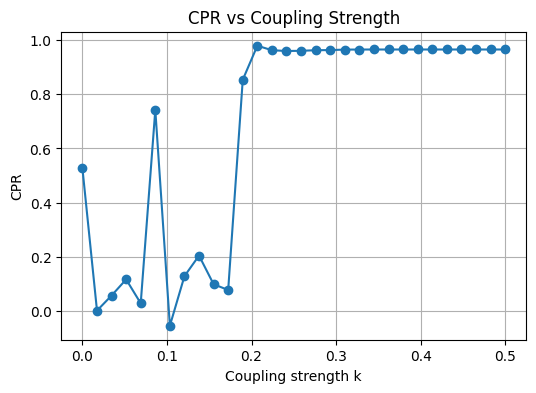

In [161]:
from scipy.integrate import solve_ivp
from pyunicorn.timeseries import RecurrencePlot
import numpy as np
import matplotlib.pyplot as plt

k_values = np.linspace(0, 0.5, 30)
cpr_values = []

for k in k_values:

    xd, xr = coupled_rossler_delay(dt = 0.025, k=k)

    # remove transient
    xd = xd.T[5000:]
    xr = xr.T[5000:]

    # normalize
    #xd = (xd - np.mean(xd)) / np.std(xd)
    #xr = (xr - np.mean(xr)) / np.std(xr)

    # recurrence plots
    rp_drive = RecurrencePlot(xd, metric="euclidean", recurrence_rate=0.1)
    rp_response = RecurrencePlot(xr, metric="euclidean", recurrence_rate=0.1)

    RP_drive = rp_drive.recurrence_matrix()
    RP_response = rp_response.recurrence_matrix()

    C = rec.cpr(RP_drive, RP_response)
    cpr_values.append(C)

# Plot CPR vs k
plt.figure(figsize=(6,4))
plt.plot(k_values, cpr_values, marker='o')
plt.xlabel("Coupling strength k")
plt.ylabel("CPR")
plt.title("CPR vs Coupling Strength")
plt.grid(True)
plt.show()

Save time series

No Synch

In [13]:
nosynch1, nosynch2 = coupled_rossler_delay(dt = 0.025, k=0.011)

Synch seems to be sensible to dt

In [14]:
nosynch1 = nosynch1.T[5000:]
nosynch2 = nosynch2.T[5000:]

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

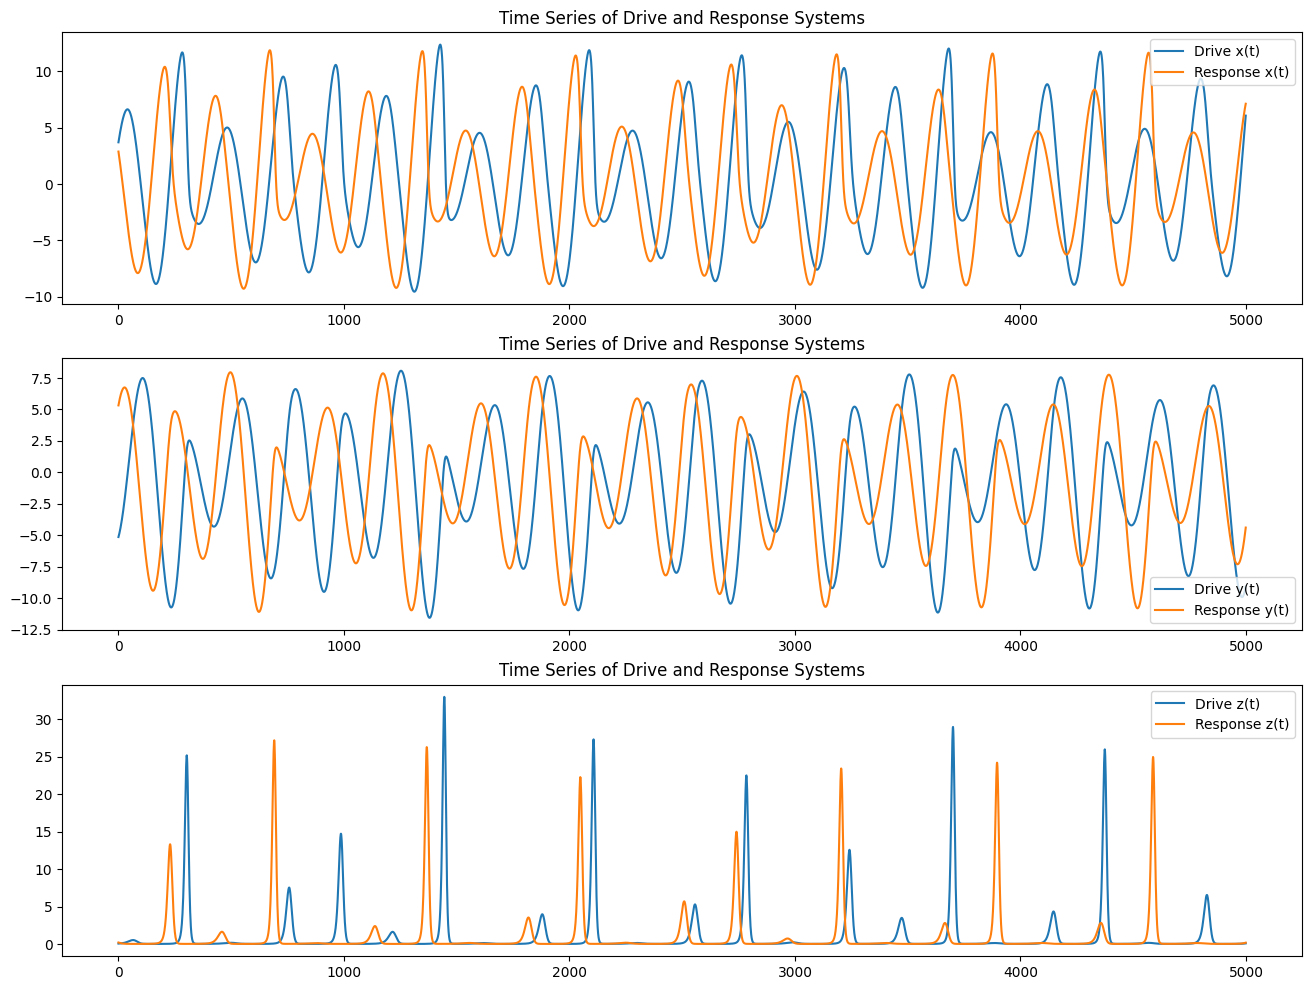

In [6]:
# plot time series
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))

steps = 2000
plt.subplot(3, 1, 1)
plt.plot(nosynch1.T[0], label='Drive x(t)')
plt.plot(nosynch2.T[0], label='Response x(t)')
plt.legend()
plt.title('Time Series of Drive and Response Systems')
plt.tight_layout

plt.subplot(3, 1, 2)
plt.plot(nosynch1.T[1], label='Drive y(t)')
plt.plot(nosynch2.T[1], label='Response y(t)')
plt.legend()
plt.title('Time Series of Drive and Response Systems')
plt.tight_layout

plt.subplot(3, 1, 3)
plt.plot(nosynch1.T[2], label='Drive z(t)')
plt.plot(nosynch2.T[2], label='Response z(t)')
plt.legend()
plt.title('Time Series of Drive and Response Systems')

plt.tight_layout

In [7]:
RX_nosynch = RecurrencePlot(nosynch1, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()
RY_nosynch = RecurrencePlot(nosynch2, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()

print(rec.cpr(RX_nosynch, RY_nosynch))

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
0.15062976515139884


In [19]:
JointRecurrencePlot(nosynch1,nosynch2,recurrence_rate=(0.1,0.1), metric=('euclidean','euclidean')).recurrence_rate()

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...


0.0281976

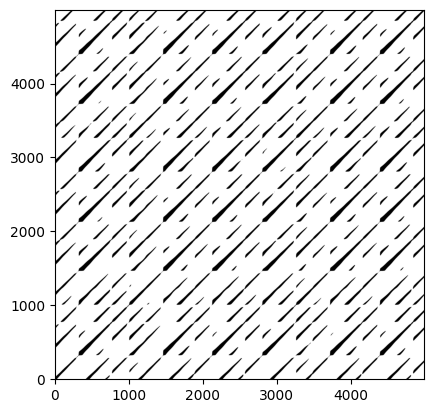

In [8]:
fig, ax = plt.subplots()
ax.imshow(RX_nosynch, cmap='binary', origin='lower')

In [2]:
import pandas as pd
import numpy as np

In [15]:
# convert arrays into dataframe
DF1 = pd.DataFrame(nosynch1)
DF2 = pd.DataFrame(nosynch2)

# save the dataframe as a csv file
#DF1.to_csv("LS_nosynch1.csv", index=False)
#DF2.to_csv("LS_nosynch2.csv", index=False)

Synch

In [6]:
synch1, synch2 = coupled_rossler_delay(dt = 0.025, k=0.2)

In [7]:
synch1 = synch1.T[5000:]
synch2 = synch2.T[5000:]

In [8]:
# normalization
synch1 = (synch1 - np.mean(synch1, axis = 0)) / np.std(synch1, axis = 0)
synch2 = (synch2 - np.mean(synch2, axis = 0)) / np.std(synch2, axis = 0)

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

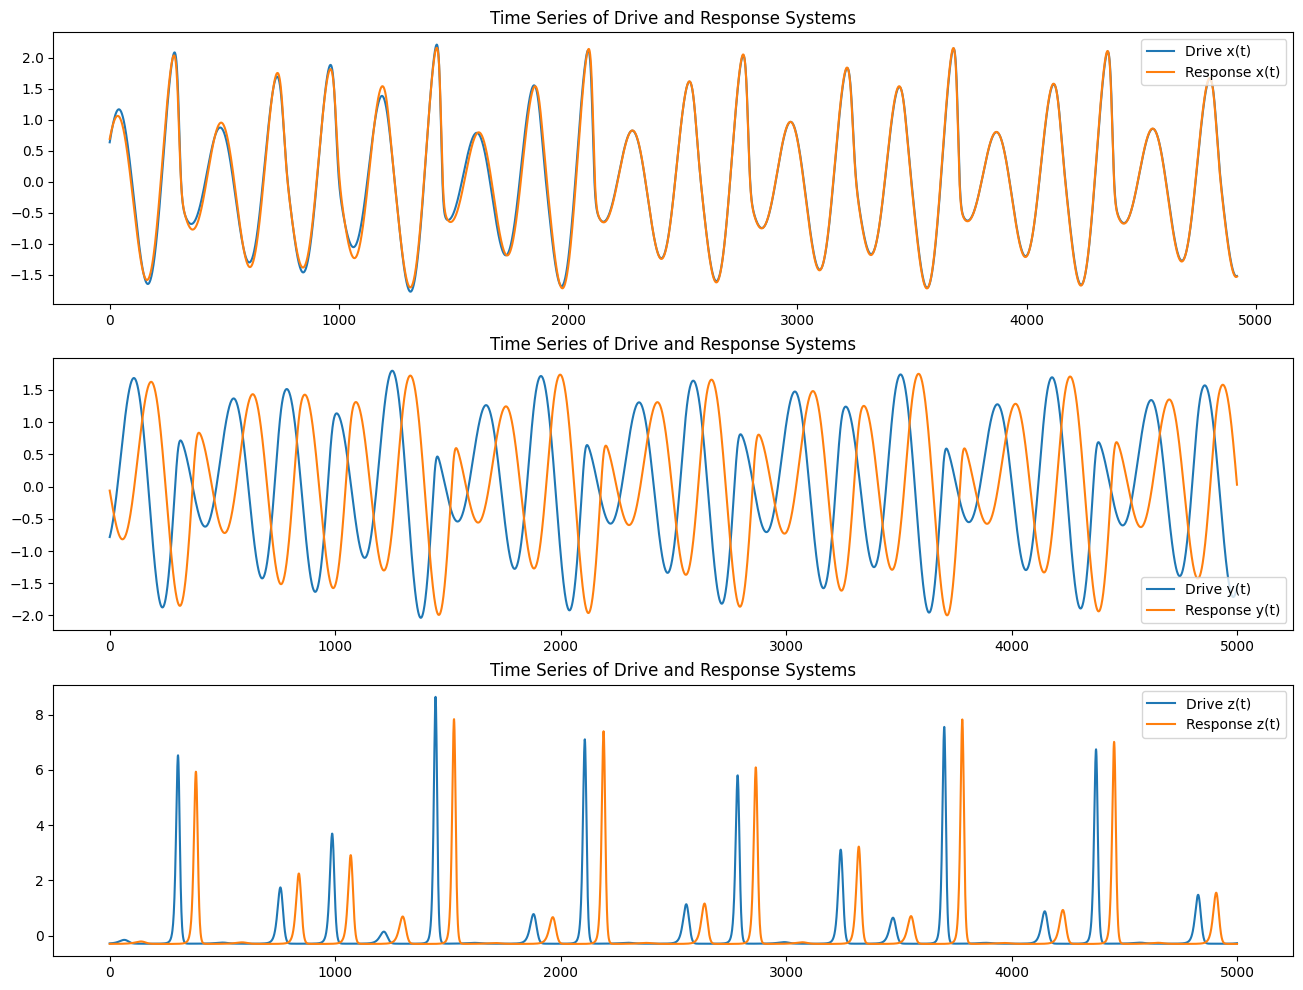

In [12]:
# plot time series
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))

steps = 2000
plt.subplot(3, 1, 1)
plt.plot(synch1.T[0][:-81], label='Drive x(t)')
plt.plot(synch2.T[0][81:], label='Response x(t)')
plt.legend()
plt.title('Time Series of Drive and Response Systems')
plt.tight_layout

plt.subplot(3, 1, 2)
plt.plot(synch1.T[1], label='Drive y(t)')
plt.plot(synch2.T[1], label='Response y(t)')
plt.legend()
plt.title('Time Series of Drive and Response Systems')
plt.tight_layout

plt.subplot(3, 1, 3)
plt.plot(synch1.T[2], label='Drive z(t)')
plt.plot(synch2.T[2], label='Response z(t)')
plt.legend()
plt.title('Time Series of Drive and Response Systems')

plt.tight_layout

Amplitudes highly correlated and lagged. Works

In [20]:
RX_synch = RecurrencePlot(synch1, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()
RY_synch = RecurrencePlot(synch2, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()

print(rec.cpr(RX_synch, RY_synch))

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
0.9617583496092031


In [ ]:
# convert arrays into dataframe
DF1 = pd.DataFrame(synch1)
DF2 = pd.DataFrame(synch2)

# save the dataframe as a csv file
#DF1.to_csv("LS_synch1.csv", index=False)
#DF2.to_csv("LS_synch2.csv", index=False)

In [6]:

#Import models
nosynch1 = pd.read_csv('LS_nosynch1.csv').to_numpy()

nosynch2 = pd.read_csv('LS_nosynch2.csv').to_numpy()

synch1 = pd.read_csv('LS_synch1.csv').to_numpy()

synch2 = pd.read_csv('LS_synch2.csv').to_numpy()

In [7]:
RX_nosynch = RecurrencePlot(nosynch1, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()
RY_nosynch = RecurrencePlot(nosynch2, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()

RX_synch = RecurrencePlot(synch1, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()
RY_synch = RecurrencePlot(synch2, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()


Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


In [8]:
px_nosynch = rec.tau_recurrence(RX_nosynch)
py_nosynch = rec.tau_recurrence(RY_nosynch)

px_synch = rec.tau_recurrence(RX_synch)
py_synch = rec.tau_recurrence(RY_synch)

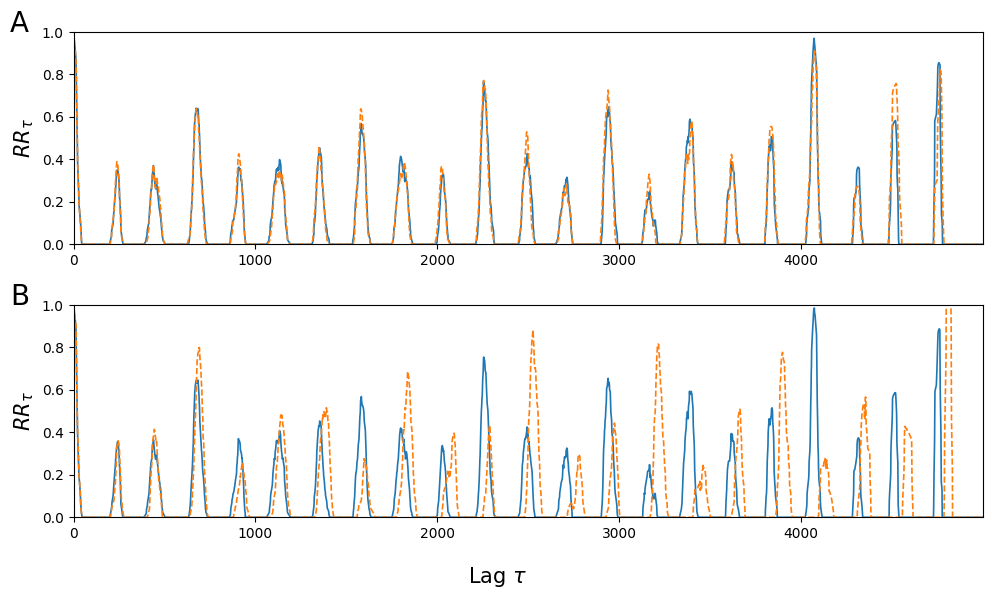

In [12]:
import string

# Visualize
fig, axs = plt.subplots(2,1,figsize=(10, 6))

taus = np.arange(0,len(px_nosynch))

axs[0].plot(taus, px_synch, linewidth = 1.2)
axs[0].plot(taus, py_synch, linestyle='dashed', linewidth = 1.2)

axs[0].margins(0) 

#axs.set_xticks(np.arange(0,len(tau_rr_embed),50))

axs[0].set_ylabel(r'$RR_{\tau}$', fontsize = 15)
axs[0].text(-0.07, 1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)

# Plot each graph, and manually set the y tick values
axs[1].plot(taus, px_nosynch, linewidth = 1.2)
axs[1].plot(taus, py_nosynch, linestyle='dashed', linewidth = 1.2)

axs[1].margins(0) 

#axs.set_xticks(np.arange(0,len(tau_rr_embed),50))

axs[1].set_ylabel(r'$RR_{\tau}$', fontsize = 15)
axs[1].text(-0.07, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=20)
#axs.set_title('Embedded time series')


fig.supxlabel(r'Lag $\tau$', fontsize = 15)

plt.tight_layout()

plt.show()

fig.savefig('RRT_LS.pdf', dpi = 300)